# Quantium Data Analytics Virtual Experience — Task 1 & 2

Working through the Quantium retail analytics tasks. The goal is to help a chips category manager understand buying patterns and test whether a store trial actually worked.

**Dataset:** Transaction data + customer loyalty data (Jul 2018 – Jun 2019)  
**Tools:** Python, pandas, matplotlib, seaborn, scipy

---
## Task 1 — Data Cleaning & Customer Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:


txn = pd.read_excel('/content/QVI_transaction_data (1).xlsx')
cust = pd.read_csv('/content/QVI_purchase_behaviour (1).csv')

print(txn.shape, cust.shape)

(264836, 8) (72637, 3)


In [3]:
txn.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
txn.dtypes

,0
DATE,int64
STORE_NBR,int64
LYLTY_CARD_NBR,int64
TXN_ID,int64
PROD_NBR,int64
PROD_NAME,object
PROD_QTY,int64
TOT_SALES,float64


In [5]:
# DATE column is coming in as an integer - excel serial format
# origin is 1899-12-30 for excel
txn['DATE'] = pd.to_datetime(txn['DATE'], origin='1899-12-30', unit='D')
txn['DATE'].dtype

dtype('<M8[ns]')

In [8]:
# checking what products we have - want to make sure these are all chips
txn['PROD_NAME'].value_counts().head(20)

,count
PROD_NAME,
Kettle Mozzarella Basil & Pesto 175g,3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g,3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3269
Tyrrells Crisps Ched & Chives 165g,3268
Cobs Popd Sea Salt Chips 110g,3265
Kettle 135g Swt Pot Sea Salt,3257
Tostitos Splash Of Lime 175g,3252
Infuzions Thai SweetChili PotatoMix 110g,3242
Smiths Crnkle Chip Orgnl Big Bag 380g,3233


In [9]:
txn['PROD_NAME'].value_counts().tail(20)

,count
PROD_NAME,
Smiths Crinkle Cut Chips Original 170g,1461
Smiths Thinly Swt Chli&S/Cream175G,1461
Natural ChipCo Hony Soy Chckn175g,1460
Red Rock Deli SR Salsa & Mzzrlla 150g,1458
Smiths Crinkle Cut Salt & Vinegar 170g,1455
RRD Steak & Chimuchurri 150g,1455
Cheezels Cheese Box 125g,1454
Smith Crinkle Cut Bolognese 150g,1451
Doritos Salsa Medium 300g,1449


In [10]:
# noticed salsa products in there - not chips, need to remove
txn = txn[~txn['PROD_NAME'].str.contains('salsa', case=False, na=False)].copy()
print('rows after removing salsa:', len(txn))

rows after removing salsa: 246742


In [11]:
txn[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,246742.000000,246742.000000
mean,1.908062,7.321322
std,0.659831,3.077828
min,1.000000,1.700000
25%,2.000000,5.800000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,200.000000,650.000000


In [12]:
# max qty is 200 - that's way too high, let's look at it
txn[txn['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [13]:
# same loyalty card, same store, only 2 transactions all year - looks like a bulk/commercial buyer
# removing this since it's not a regular retail customer
txn = txn[txn['LYLTY_CARD_NBR'] != 226000].copy()
print('rows after removing outlier:', len(txn))

rows after removing outlier: 246740


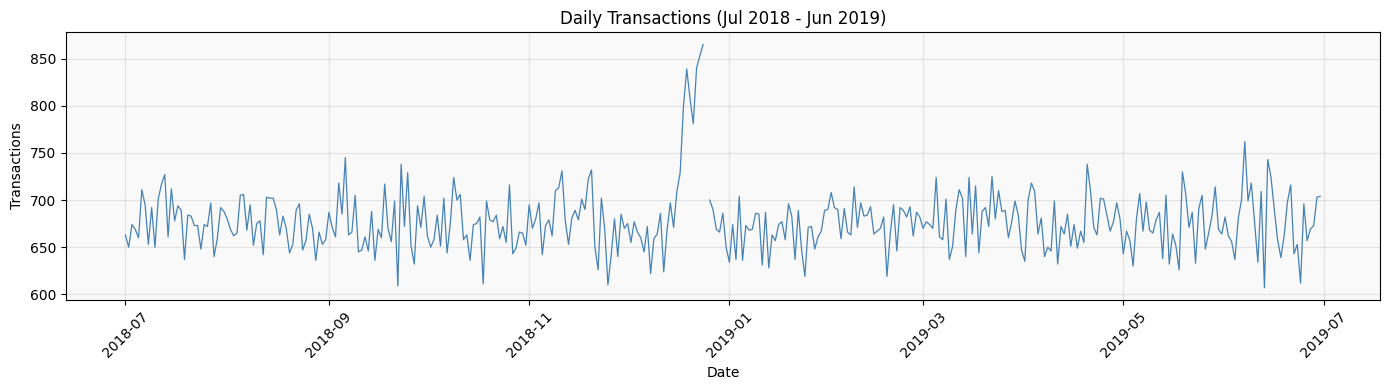

In [14]:
# transactions over time - check for any weird gaps
by_day = txn.groupby('DATE').size().reset_index(name='count')
all_dates = pd.DataFrame({'DATE': pd.date_range('2018-07-01', '2019-06-30')})
by_day = all_dates.merge(by_day, on='DATE', how='left')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(by_day['DATE'], by_day['count'], color='steelblue', linewidth=0.9)
ax.set_title('Daily Transactions (Jul 2018 - Jun 2019)')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

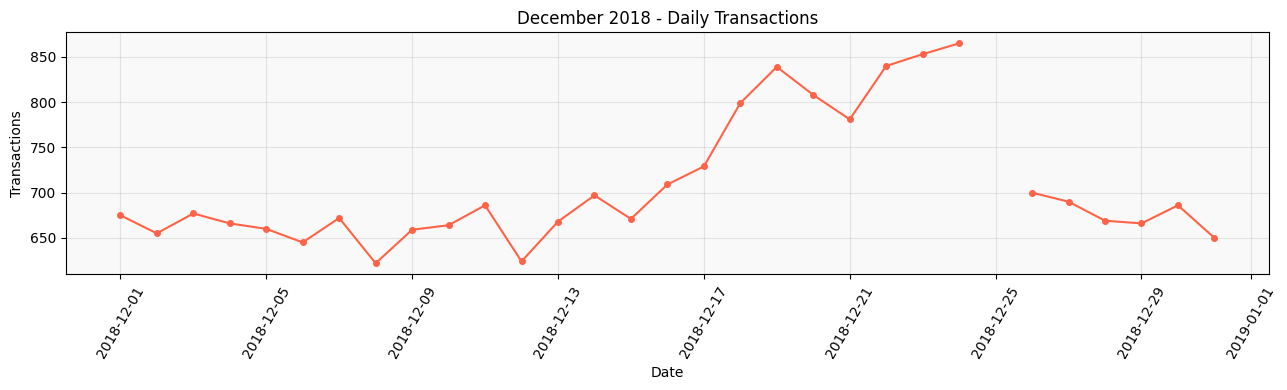

In [15]:
# spike in december then a zero - zooming in
dec = by_day[by_day['DATE'].dt.month == 12]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dec['DATE'], dec['count'], color='tomato', marker='o', markersize=4, linewidth=1.5)
ax.set_title('December 2018 - Daily Transactions')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# zero on dec 25 = Christmas, stores closed. makes sense

In [16]:
# pull pack size from product name - it's the number before 'g'
txn['PACK_SIZE'] = txn['PROD_NAME'].str.extract(r'(\d+)g').astype(float)
txn['PACK_SIZE'].value_counts().sort_index()

,count
PACK_SIZE,
70.0,1507
90.0,3008
110.0,22387
125.0,1454
134.0,25102
135.0,3257
150.0,38705
160.0,2970
165.0,15297


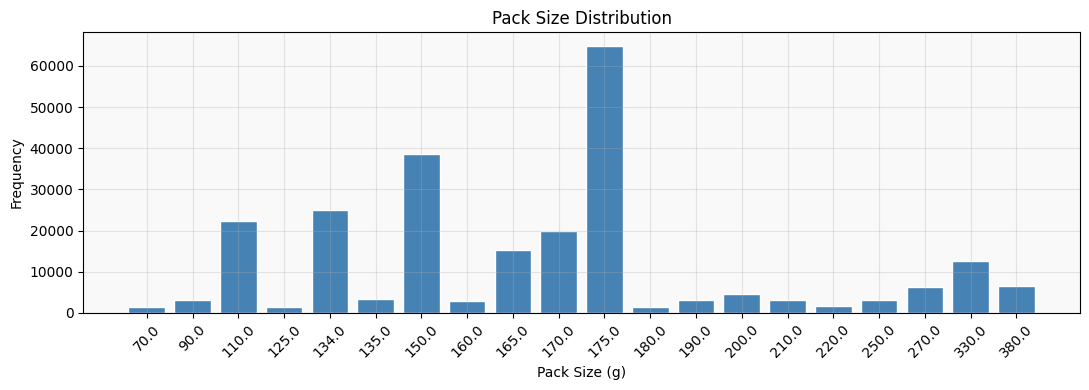

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
pack_counts = txn['PACK_SIZE'].value_counts().sort_index()
ax.bar(pack_counts.index.astype(str), pack_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Pack Size Distribution')
ax.set_xlabel('Pack Size (g)')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# brand = first word of product name
txn['BRAND'] = txn['PROD_NAME'].str.split().str[0].str.upper()

# some brands have multiple names e.g. SMITH vs SMITHS, WW vs WOOLWORTHS
fix_brands = {
    'RED': 'RRD',
    'SNBTS': 'SUNBITES',
    'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS',
    'SMITH': 'SMITHS',
    'NCC': 'NATURAL',
    'DORITO': 'DORITOS',
    'GRAIN': 'GRNWVES'
}
txn['BRAND'] = txn['BRAND'].replace(fix_brands)
txn['BRAND'].value_counts()

,count
BRAND,
KETTLE,41288
SMITHS,30353
DORITOS,25224
PRINGLES,25102
RRD,16321
INFUZIONS,14201
THINS,14075
WOOLWORTHS,11836
COBS,9693


In [19]:
# quick look at customer data
cust.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [20]:
cust.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [21]:
print(cust['LIFESTAGE'].value_counts())
print()
print(cust['PREMIUM_CUSTOMER'].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [22]:
# merge
df = txn.merge(cust, on='LYLTY_CARD_NBR', how='left')
print(df.shape)
print('nulls after merge:', df['LIFESTAGE'].isnull().sum())

(246740, 12)
nulls after merge: 0


### Customer Segment Analysis

Now looking at which segments buy the most chips, broken down by lifestage and spending tier.

In [23]:
# total sales by segment
sales_by_seg = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_by_seg = sales_by_seg.sort_values('TOT_SALES', ascending=False)
sales_by_seg.head(10)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123537.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


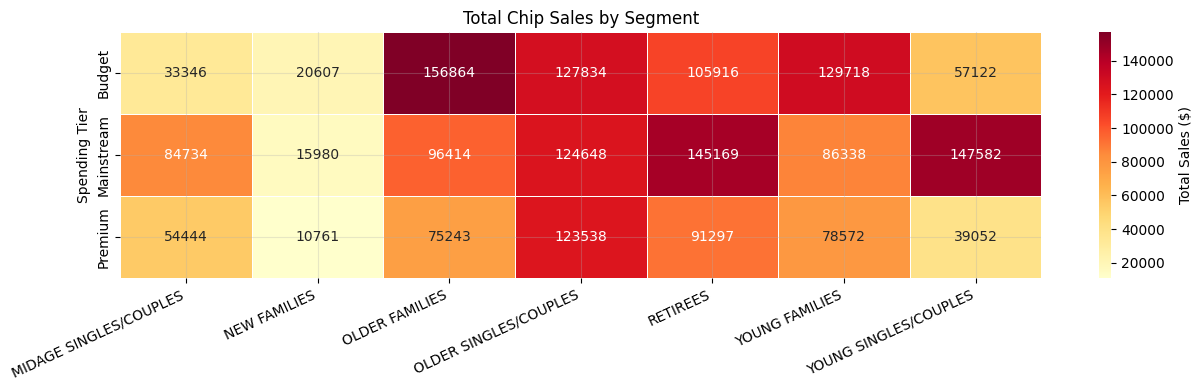

In [24]:
pivot_sales = sales_by_seg.pivot(index='PREMIUM_CUSTOMER', columns='LIFESTAGE', values='TOT_SALES')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Total Sales ($)'})
ax.set_title('Total Chip Sales by Segment')
ax.set_xlabel('')
ax.set_ylabel('Spending Tier')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# top: Budget-Older Families, Mainstream-Young Singles/Couples, Mainstream-Retirees

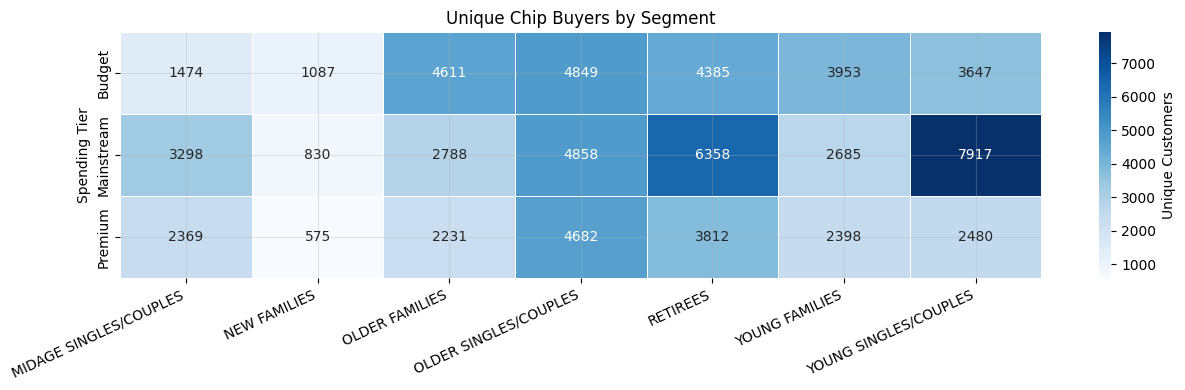

In [25]:
# is it more customers or more spend per customer driving this?
custs_by_seg = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
custs_by_seg.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'N_CUSTOMERS']

pivot_custs = custs_by_seg.pivot(index='PREMIUM_CUSTOMER', columns='LIFESTAGE', values='N_CUSTOMERS')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_custs, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Unique Customers'})
ax.set_title('Unique Chip Buyers by Segment')
ax.set_xlabel('')
ax.set_ylabel('Spending Tier')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

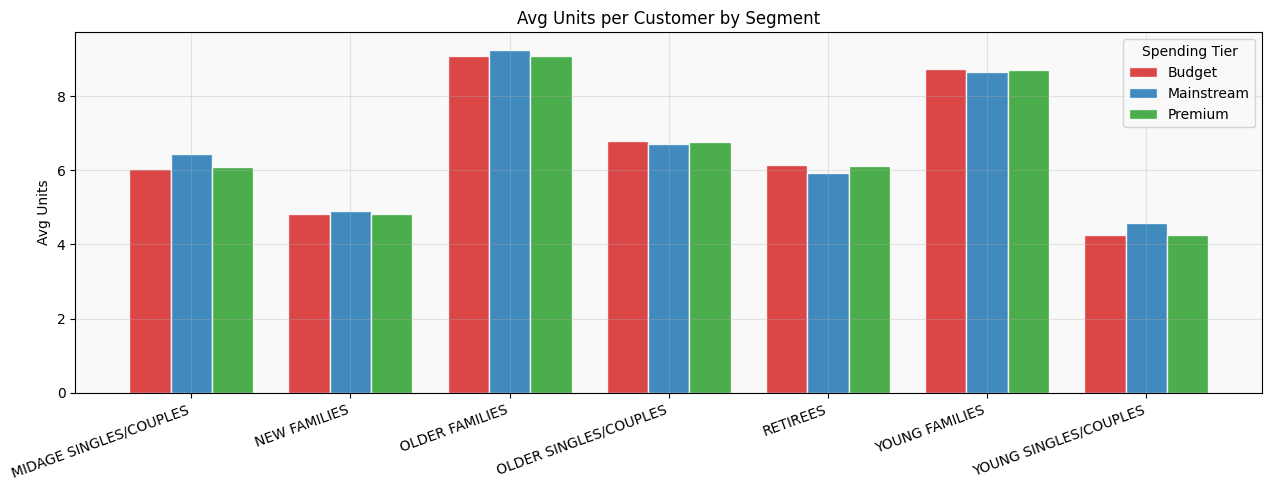

In [26]:
# avg units per customer
avg_units = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .apply(lambda x: x['PROD_QTY'].sum() / x['LYLTY_CARD_NBR'].nunique())
    .reset_index(name='AVG_UNITS')
)

lifestages = sorted(avg_units['LIFESTAGE'].unique())
tiers = ['Budget', 'Mainstream', 'Premium']
colors = ['#d62728', '#1f77b4', '#2ca02c']
x = np.arange(len(lifestages))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
for i, (tier, col) in enumerate(zip(tiers, colors)):
    sub = avg_units[avg_units['PREMIUM_CUSTOMER'] == tier].set_index('LIFESTAGE')
    vals = [sub.loc[ls, 'AVG_UNITS'] if ls in sub.index else 0 for ls in lifestages]
    ax.bar(x + i*w, vals, w, label=tier, color=col, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(lifestages, rotation=20, ha='right')
ax.set_title('Avg Units per Customer by Segment')
ax.set_ylabel('Avg Units')
ax.legend(title='Spending Tier')
plt.tight_layout()
plt.show()

# older families and young families buy the most per customer

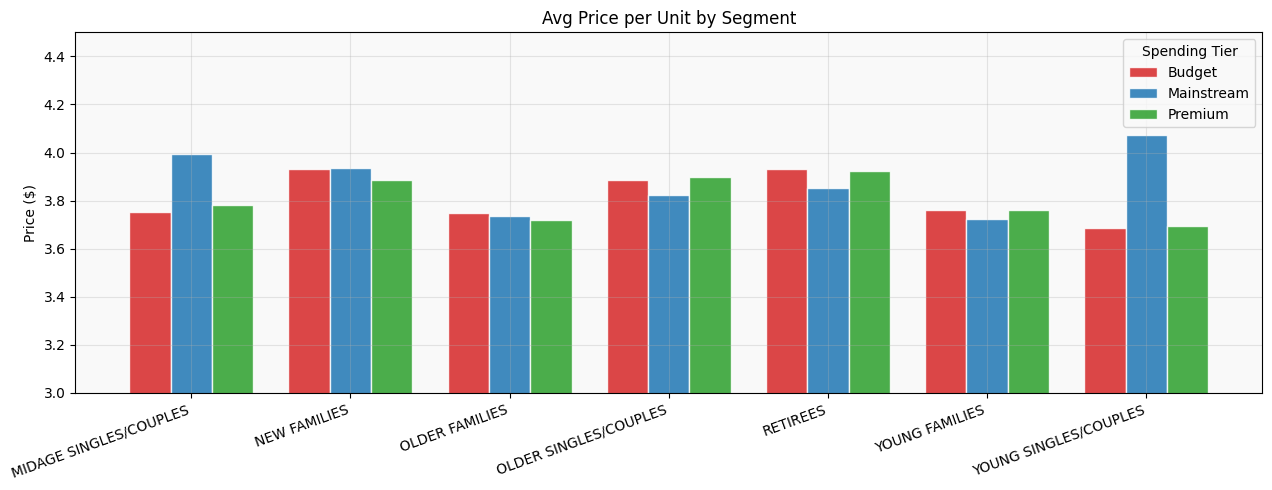

In [27]:
# avg price per unit - do some segments pay more?
avg_price = (
    df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .apply(lambda x: x['TOT_SALES'].sum() / x['PROD_QTY'].sum())
    .reset_index(name='AVG_PRICE')
)

fig, ax = plt.subplots(figsize=(13, 5))
for i, (tier, col) in enumerate(zip(tiers, colors)):
    sub = avg_price[avg_price['PREMIUM_CUSTOMER'] == tier].set_index('LIFESTAGE')
    vals = [sub.loc[ls, 'AVG_PRICE'] if ls in sub.index else 0 for ls in lifestages]
    ax.bar(x + i*w, vals, w, label=tier, color=col, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(lifestages, rotation=20, ha='right')
ax.set_title('Avg Price per Unit by Segment')
ax.set_ylabel('Price ($)')
ax.set_ylim(3.0, 4.5)
ax.legend(title='Spending Tier')
plt.tight_layout()
plt.show()

In [28]:
# mainstream young + midage singles seem to pay more per unit than their budget/premium counterparts
# t-test to confirm

df['price_per_unit'] = df['TOT_SALES'] / df['PROD_QTY']

target_ls = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

mainstream = df[
    df['LIFESTAGE'].isin(target_ls) & (df['PREMIUM_CUSTOMER'] == 'Mainstream')
]['price_per_unit']

non_mainstream = df[
    df['LIFESTAGE'].isin(target_ls) & (df['PREMIUM_CUSTOMER'] != 'Mainstream')
]['price_per_unit']

t, p = stats.ttest_ind(mainstream, non_mainstream, alternative='greater')

print(f'Mainstream mean: {mainstream.mean():.4f}')
print(f'Others mean:     {non_mainstream.mean():.4f}')
print(f't-stat: {t:.2f}, p-value: {p:.2e}')

# p < 0.05, so yes - mainstream young/midage singles genuinely pay more per pack
# probably impulse buying rather than planned purchases

Mainstream mean: 4.0398
Others mean:     3.7065
t-stat: 37.83, p-value: 1.12e-309


yes the difference you see in the chart is real, not just noise

p < 1.12e-309, way below 0.05 - mainstream young/midage singles genuinely pay more per pack

likely impulse buying rather than planned purchases

### Deep Dive - Mainstream Young Singles/Couples

One of the top segments by sales. Checking which brands and pack sizes they prefer vs everyone else.

In [34]:
seg = df[(df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df['PREMIUM_CUSTOMER'] == 'Mainstream')].copy()
rest = df[~((df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df['PREMIUM_CUSTOMER'] == 'Mainstream'))].copy()

qty_seg  = seg['PROD_QTY'].sum()
qty_rest = rest['PROD_QTY'].sum()

brand_seg  = seg.groupby('BRAND')['PROD_QTY'].sum() / qty_seg
brand_rest = rest.groupby('BRAND')['PROD_QTY'].sum() / qty_rest

brand_aff = pd.DataFrame({'seg': brand_seg, 'rest': brand_rest}).dropna()
brand_aff['affinity'] = brand_aff['seg'] / brand_aff['rest']
brand_aff = brand_aff.sort_values('affinity', ascending=False)
brand_aff

,seg,rest,affinity
BRAND,,,
TYRRELLS,0.031553,0.025692,1.228095
TWISTIES,0.046184,0.037877,1.219319
DORITOS,0.122761,0.101075,1.214553
KETTLE,0.197985,0.165553,1.195897
TOSTITOS,0.045411,0.037978,1.195713
PRINGLES,0.119420,0.100635,1.186670
COBS,0.044638,0.039049,1.143124
INFUZIONS,0.064679,0.057065,1.133435
THINS,0.060373,0.056986,1.059423


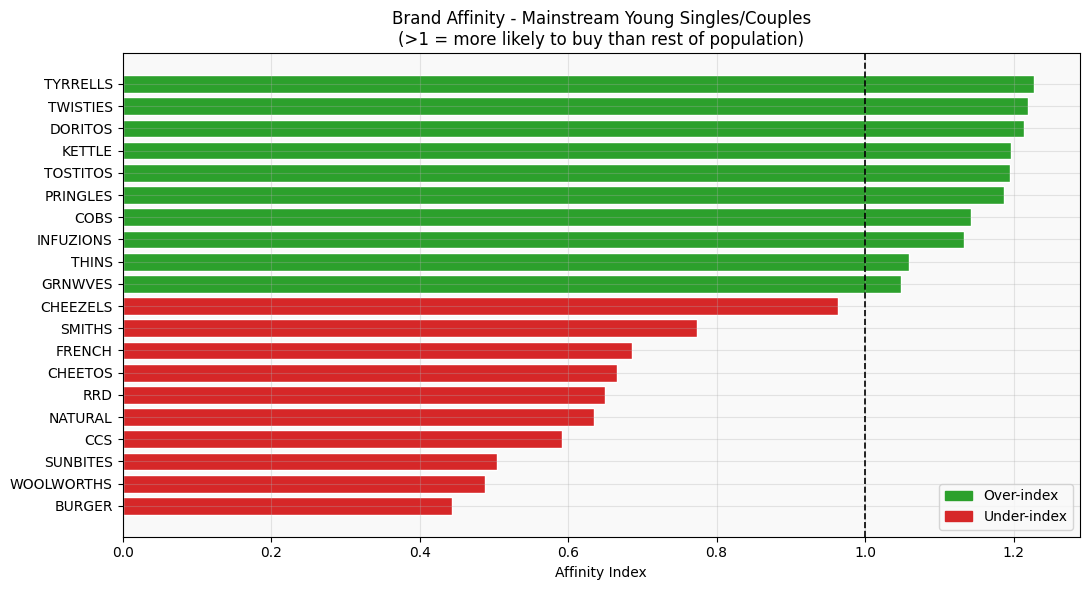

Top brand: TYRRELLS (1.23x more likely)
Least likely: BURGER (0.44x)


In [35]:
fig, ax = plt.subplots(figsize=(11, 6))
clrs = ['#2ca02c' if v > 1 else '#d62728' for v in brand_aff['affinity']]
ax.barh(brand_aff.index[::-1], brand_aff['affinity'][::-1], color=clrs[::-1], edgecolor='white')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_title('Brand Affinity - Mainstream Young Singles/Couples\n(>1 = more likely to buy than rest of population)')
ax.set_xlabel('Affinity Index')

green_p = mpatches.Patch(color='#2ca02c', label='Over-index')
red_p   = mpatches.Patch(color='#d62728', label='Under-index')
ax.legend(handles=[green_p, red_p])
plt.tight_layout()
plt.show()

print(f"Top brand: {brand_aff.index[0]} ({brand_aff.iloc[0]['affinity']:.2f}x more likely)")
print(f"Least likely: {brand_aff.index[-1]} ({brand_aff.iloc[-1]['affinity']:.2f}x)")

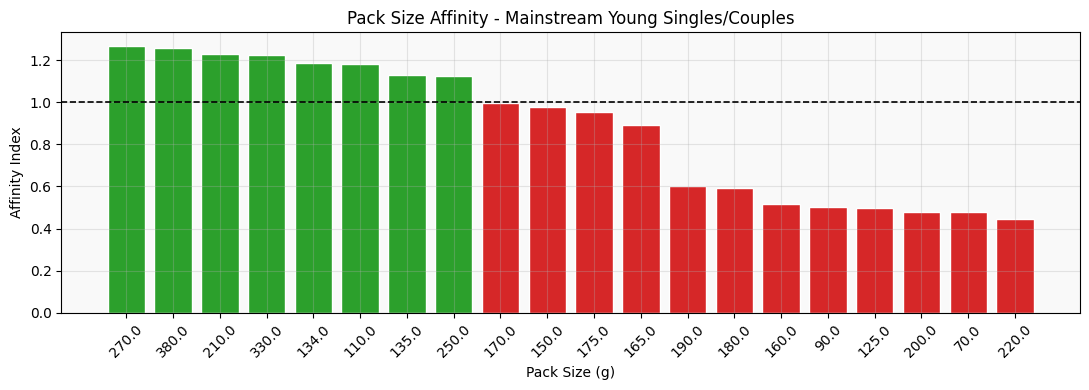

In [36]:
# pack size affinity
pack_seg  = seg.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_seg
pack_rest = rest.groupby('PACK_SIZE')['PROD_QTY'].sum() / qty_rest

pack_aff = pd.DataFrame({'seg': pack_seg, 'rest': pack_rest}).dropna()
pack_aff['affinity'] = pack_aff['seg'] / pack_aff['rest']
pack_aff = pack_aff.sort_values('affinity', ascending=False)

clrs_p = ['#2ca02c' if v > 1 else '#d62728' for v in pack_aff['affinity']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(pack_aff.index.astype(str), pack_aff['affinity'], color=clrs_p, edgecolor='white')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_title('Pack Size Affinity - Mainstream Young Singles/Couples')
ax.set_xlabel('Pack Size (g)')
ax.set_ylabel('Affinity Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# 270g is the most over-indexed - which brand sells that?
df[df['PACK_SIZE'] == 270]['PROD_NAME'].unique()
# only Twisties - the 270g preference is really a Twisties preference

array(['Twisties Cheese     270g', 'Twisties Chicken270g'], dtype=object)

**Task 1 takeaways:**

- Mainstream Young Singles/Couples and Mainstream Retirees are top segments by sales - mainly because there are a lot of them, not because each person spends more
- Budget Older Families spend a lot because they buy more units per customer
- Mainstream young/midage singles pay more per pack (t-test confirms, p < 1.12e-309- likely impulse buying
- This segment over-indexes for Tyrrells (+23%), Twisties (+23%), Kettle (+20%)
- They prefer larger packs (270g, 380g)

**Recommendation:** Place Tyrrells and larger packs near areas these customers pass through (e.g. near checkout, beverages) to capture impulse purchases.

---
## Task 2 - Trial Store Analysis

Stores 77, 86, 88 ran a trial (new chip shelf layout) Feb-Apr 2019. Need to find matching control stores and check if the trial actually did anything.

In [38]:
# monthly metrics per store
df['yearmonth'] = df['DATE'].dt.year * 100 + df['DATE'].dt.month

monthly = (
    df.groupby(['STORE_NBR', 'yearmonth'])
    .agg(
        tot_sales   = ('TOT_SALES', 'sum'),
        n_customers = ('LYLTY_CARD_NBR', 'nunique')
    )
    .reset_index()
)

monthly.head()

,STORE_NBR,yearmonth,tot_sales,n_customers
0,1,201807,188.9,47
1,1,201808,168.4,41
2,1,201809,268.1,57
3,1,201810,175.4,39
4,1,201811,184.8,44


In [40]:
# only keep stores with 12 months of data (full year)
full_stores = monthly.groupby('STORE_NBR').filter(lambda x: len(x) == 12)['STORE_NBR'].unique()
pre = monthly[(monthly['yearmonth'] < 201902) & (monthly['STORE_NBR'].isin(full_stores))]

print(f'stores with full observation: {len(full_stores)}')
print(f'pre-trial months: {pre["yearmonth"].nunique()}')

stores with full observation: 259
pre-trial months: 7


In [41]:
# control store matching
# for each trial store, find the store that looks most similar before the trial
# scoring = correlation (trend similarity) + magnitude (level similarity)

def get_corr(pre_df, metric, trial):
    trial_vals = pre_df[pre_df['STORE_NBR'] == trial][metric].values
    rows = []
    for s in pre_df['STORE_NBR'].unique():
        other = pre_df[pre_df['STORE_NBR'] == s][metric].values
        if len(trial_vals) == len(other) and len(other) > 1:
            r = np.corrcoef(trial_vals, other)[0, 1]
            rows.append({'store': s, 'corr': r})
    return pd.DataFrame(rows)


def get_magnitude(pre_df, metric, trial):
    t_df = pre_df[pre_df['STORE_NBR'] == trial][['yearmonth', metric]]
    rows = []
    for s in pre_df['STORE_NBR'].unique():
        o_df = pre_df[pre_df['STORE_NBR'] == s][['yearmonth', metric]]
        m = t_df.merge(o_df, on='yearmonth', suffixes=('_t', '_o'))
        if len(m) > 0:
            diff = (m[f'{metric}_t'] - m[f'{metric}_o']).abs().mean()
            rows.append({'store': s, 'diff': diff})
    d = pd.DataFrame(rows)
    mn, mx = d['diff'].min(), d['diff'].max()
    d['mag'] = 1 - (d['diff'] - mn) / (mx - mn + 1e-9)
    return d[['store', 'mag']]


def find_control(pre_df, trial_store):
    c_sales = get_corr(pre_df, 'tot_sales', trial_store)
    c_custs = get_corr(pre_df, 'n_customers', trial_store)
    m_sales = get_magnitude(pre_df, 'tot_sales', trial_store)
    m_custs = get_magnitude(pre_df, 'n_customers', trial_store)

    score = (
        c_sales.merge(m_sales, on='store')
               .merge(c_custs, on='store')
               .merge(m_custs, on='store', suffixes=('_s', '_c'))
    )
    score.columns = ['store', 'corr_sales', 'mag_sales', 'corr_custs', 'mag_custs']
    score['score'] = (
        (score['corr_sales'] * 0.5 + score['mag_sales'] * 0.5) * 0.5 +
        (score['corr_custs'] * 0.5 + score['mag_custs'] * 0.5) * 0.5
    )
    score = score.sort_values('score', ascending=False)
    best = score[score['store'] != trial_store].iloc[0]['store']
    return int(best)


ctrl_77 = find_control(pre, 77)
ctrl_86 = find_control(pre, 86)
ctrl_88 = find_control(pre, 88)

print(f'Trial 77  ->  Control {ctrl_77}')
print(f'Trial 86  ->  Control {ctrl_86}')
print(f'Trial 88  ->  Control {ctrl_88}')

Trial 77  ->  Control 233
Trial 86  ->  Control 155
Trial 88  ->  Control 237


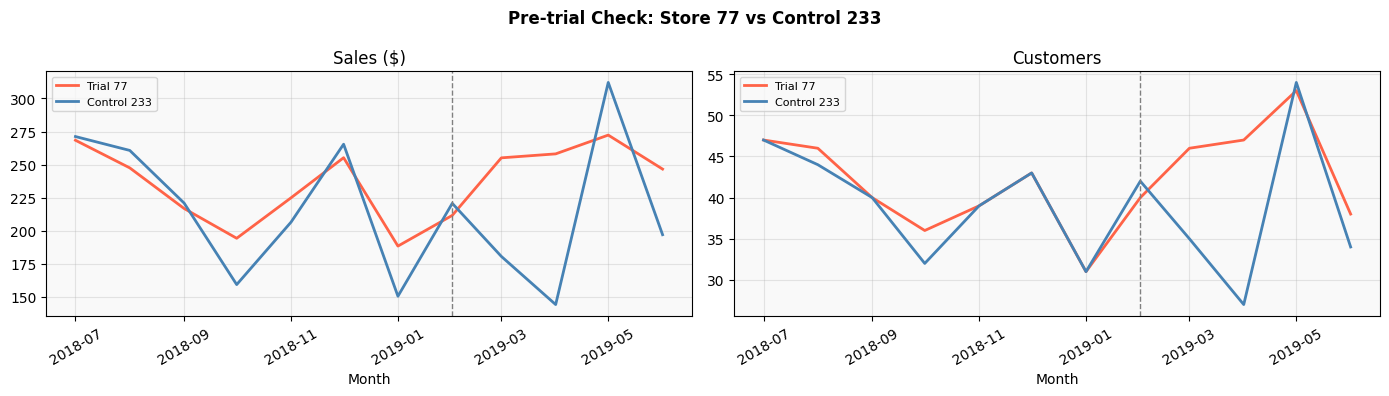

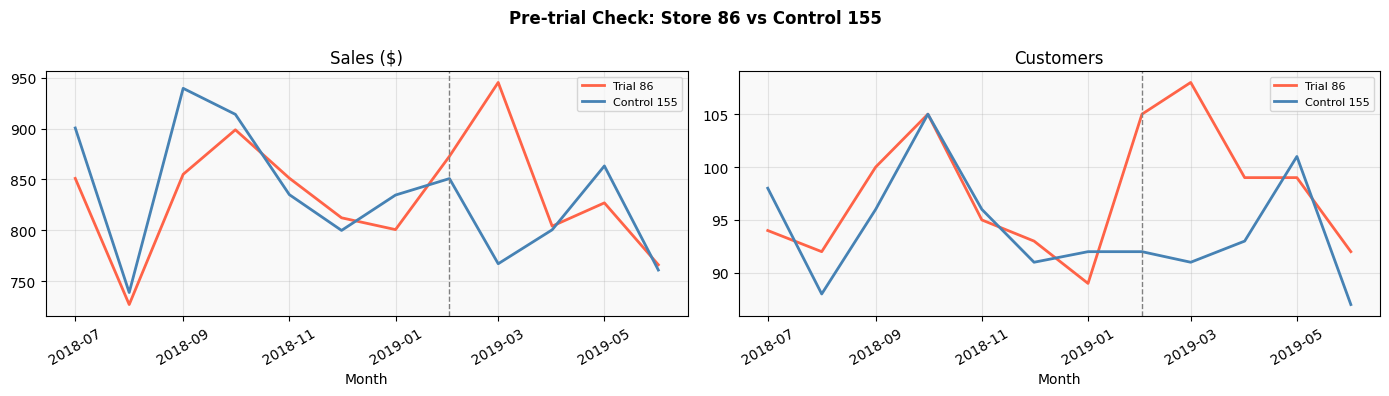

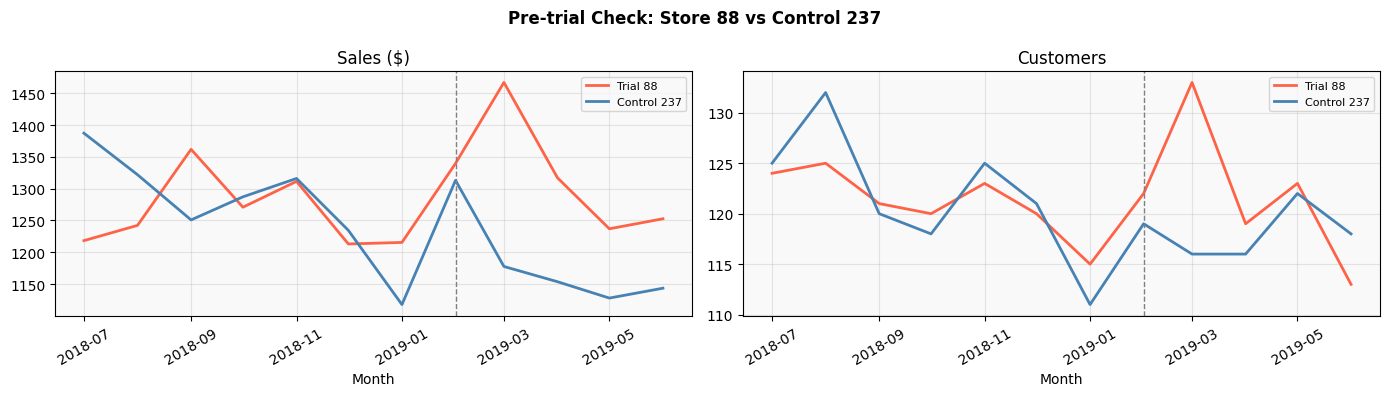

In [42]:
# visual check - do trial and control look similar before the trial?

def plot_pretrial(trial, control, monthly_df):
    t_data = monthly_df[monthly_df['STORE_NBR'] == trial].copy()
    c_data = monthly_df[monthly_df['STORE_NBR'] == control].copy()
    t_data['date'] = pd.to_datetime(t_data['yearmonth'].astype(str), format='%Y%m')
    c_data['date'] = pd.to_datetime(c_data['yearmonth'].astype(str), format='%Y%m')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for ax, col, lbl in zip([ax1, ax2], ['tot_sales', 'n_customers'], ['Sales ($)', 'Customers']):
        ax.plot(t_data['date'], t_data[col], label=f'Trial {trial}', color='tomato', linewidth=2)
        ax.plot(c_data['date'], c_data[col], label=f'Control {control}', color='steelblue', linewidth=2)
        ax.axvline(pd.Timestamp('2019-02-01'), color='grey', linestyle='--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlabel('Month')
        ax.legend(fontsize=8)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    fig.suptitle(f'Pre-trial Check: Store {trial} vs Control {control}', fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_pretrial(77, ctrl_77, monthly)
plot_pretrial(86, ctrl_86, monthly)
plot_pretrial(88, ctrl_88, monthly)

In [43]:
# trial assessment function
# scale control store to trial store level, then test if trial months fall outside the 95% CI

def assess_trial(trial, control, metric, ylabel, monthly_df, pre_df):
    t_pre = pre_df[pre_df['STORE_NBR'] == trial][metric].sum()
    c_pre = pre_df[pre_df['STORE_NBR'] == control][metric].sum()
    scale = t_pre / c_pre

    ctrl = monthly_df[monthly_df['STORE_NBR'] == control].copy()
    ctrl['scaled'] = ctrl[metric] * scale

    trial_df = monthly_df[monthly_df['STORE_NBR'] == trial][['yearmonth', metric]]
    merged = ctrl[['yearmonth', 'scaled']].merge(trial_df, on='yearmonth')
    merged['pct_diff'] = (merged['scaled'] - merged[metric]).abs() / merged['scaled']

    std = merged[merged['yearmonth'] < 201902]['pct_diff'].std()
    dof = len(merged[merged['yearmonth'] < 201902]) - 1
    t_crit = stats.t.ppf(0.95, df=dof)

    trial_months = merged[(merged['yearmonth'] >= 201902) & (merged['yearmonth'] < 201905)].copy()
    trial_months['t'] = trial_months['pct_diff'] / std

    print(f'\nTrial {trial} vs Control {control} | {ylabel}')
    print(f'scaling factor: {scale:.3f} | t-critical: {t_crit:.3f}')
    for _, r in trial_months.iterrows():
        flag = 'SIGNIFICANT' if r['t'] > t_crit else 'not significant'
        print(f"  {r['yearmonth']}: t={r['t']:.3f} - {flag}")

    ctrl['date'] = pd.to_datetime(ctrl['yearmonth'].astype(str), format='%Y%m')
    ctrl['upper'] = ctrl['scaled'] * (1 + std * 2)
    ctrl['lower'] = ctrl['scaled'] * (1 - std * 2)
    t_plot = monthly_df[monthly_df['STORE_NBR'] == trial].copy()
    t_plot['date'] = pd.to_datetime(t_plot['yearmonth'].astype(str), format='%Y%m')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axvspan(pd.Timestamp('2019-02-01'), pd.Timestamp('2019-05-01'),
               alpha=0.12, color='gold', label='Trial period')
    ax.plot(t_plot['date'], t_plot[metric], color='tomato', linewidth=2, label=f'Trial {trial}')
    ax.plot(ctrl['date'], ctrl['scaled'], color='steelblue', linewidth=2, label=f'Control {control} (scaled)')
    ax.fill_between(ctrl['date'], ctrl['lower'], ctrl['upper'],
                    alpha=0.2, color='steelblue', label='95% CI')
    ax.set_title(f'Store {trial} vs Control {control} — {ylabel}')
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


Trial 77 vs Control 233 | Total Sales ($)
scaling factor: 1.040 | t-critical: 1.943
  201902.0: t=1.224 - not significant
  201903.0: t=5.633 - SIGNIFICANT
  201904.0: t=11.337 - SIGNIFICANT


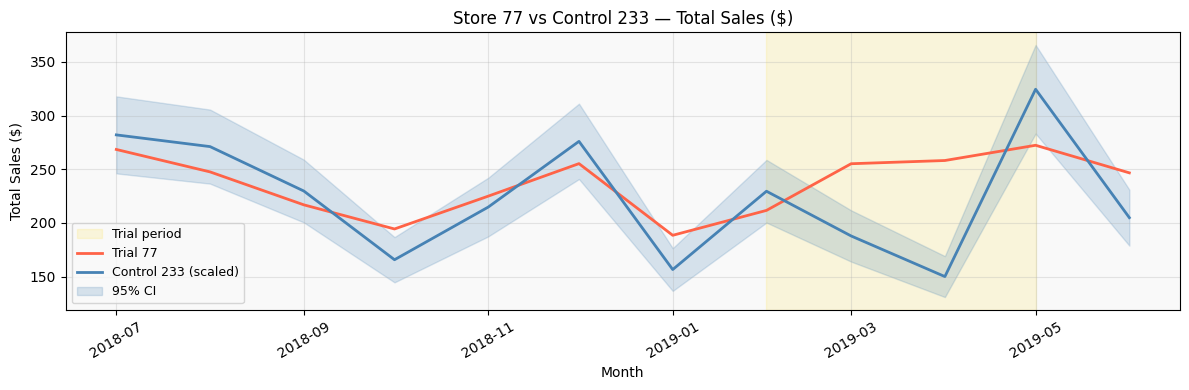


Trial 77 vs Control 233 | Customers
scaling factor: 1.022 | t-critical: 1.943
  201902.0: t=2.259 - SIGNIFICANT
  201903.0: t=9.530 - SIGNIFICANT
  201904.0: t=23.423 - SIGNIFICANT


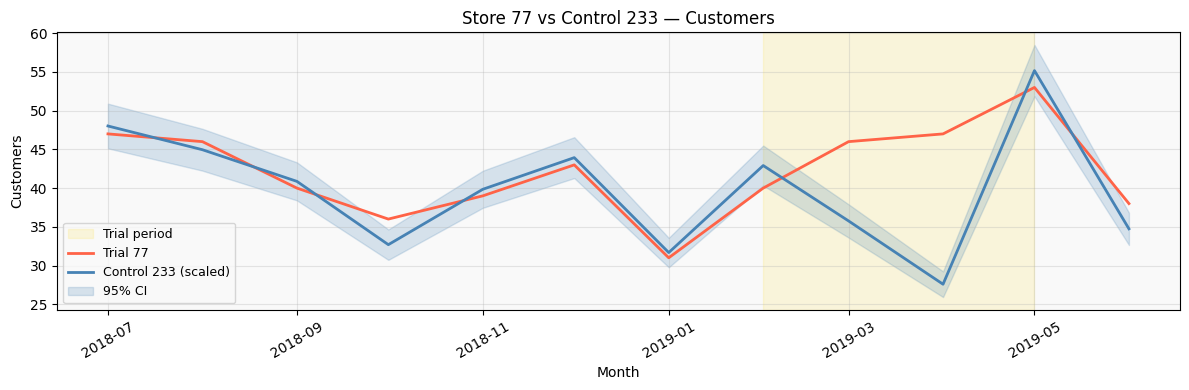

In [44]:
# store 77
assess_trial(77, ctrl_77, 'tot_sales', 'Total Sales ($)', monthly, pre)
assess_trial(77, ctrl_77, 'n_customers', 'Customers', monthly, pre)


Trial 86 vs Control 155 | Total Sales ($)
scaling factor: 0.972 | t-critical: 1.943
  201902.0: t=2.643 - SIGNIFICANT
  201903.0: t=12.797 - SIGNIFICANT
  201904.0: t=1.594 - not significant


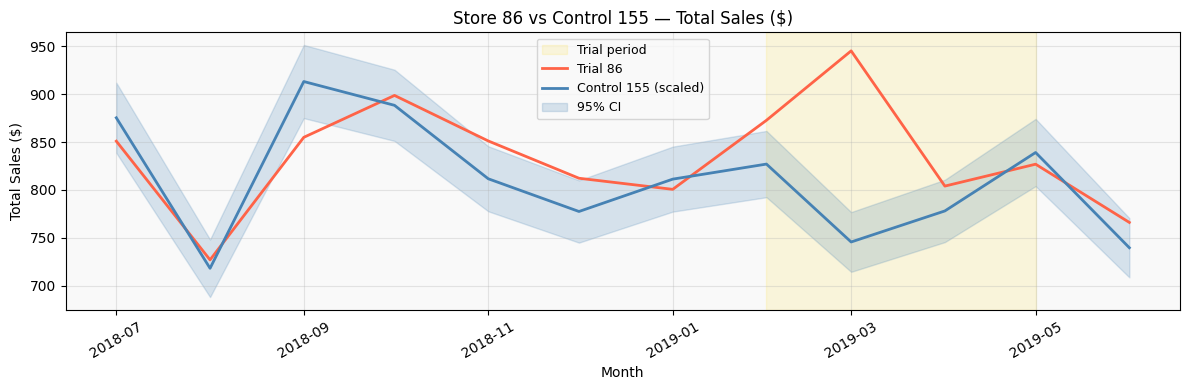


Trial 86 vs Control 155 | Customers
scaling factor: 1.003 | t-critical: 1.943
  201902.0: t=8.606 - SIGNIFICANT
  201903.0: t=11.437 - SIGNIFICANT
  201904.0: t=3.828 - SIGNIFICANT


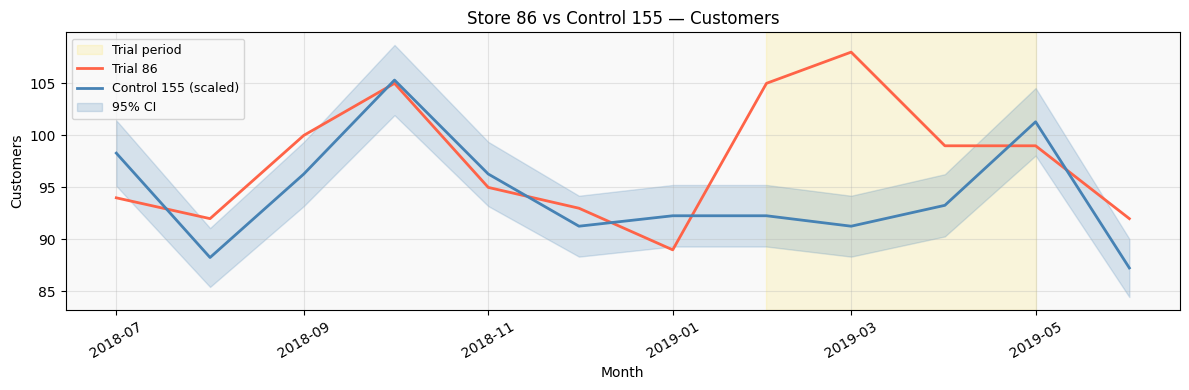

In [45]:
# store 86
assess_trial(86, ctrl_86, 'tot_sales', 'Total Sales ($)', monthly, pre)
assess_trial(86, ctrl_86, 'n_customers', 'Customers', monthly, pre)


Trial 88 vs Control 237 | Total Sales ($)
scaling factor: 0.991 | t-critical: 1.943
  201902.0: t=0.606 - not significant
  201903.0: t=5.244 - SIGNIFICANT
  201904.0: t=3.103 - SIGNIFICANT


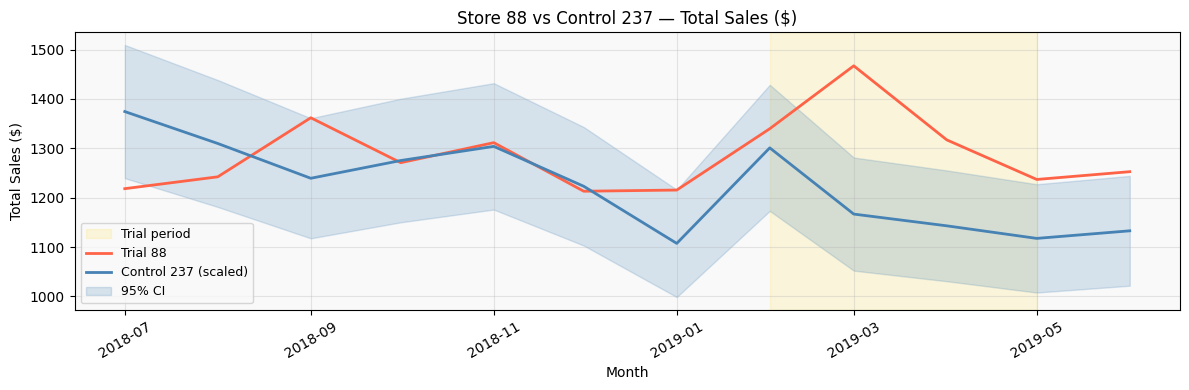


Trial 88 vs Control 237 | Customers
scaling factor: 0.995 | t-critical: 1.943
  201902.0: t=1.677 - not significant
  201903.0: t=8.482 - SIGNIFICANT
  201904.0: t=1.714 - not significant


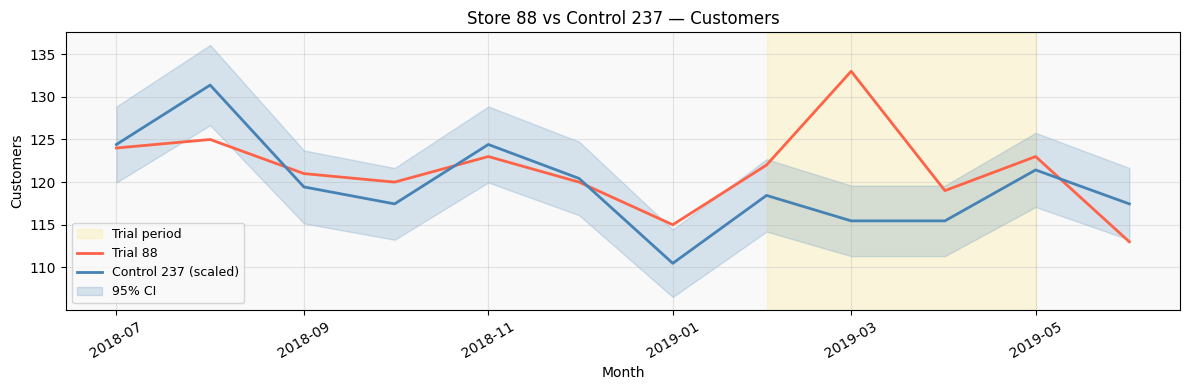

In [46]:
# store 88
assess_trial(88, ctrl_88, 'tot_sales', 'Total Sales ($)', monthly, pre)
assess_trial(88, ctrl_88, 'n_customers', 'Customers', monthly, pre)

### Task 2 Results

| Trial Store | Control | Sales uplift | Customer uplift |
|-------------|---------|-------------|----------------|
| 77 | 233 | Significant (Mar + Apr) | Significant (Mar + Apr) |
| 86 | 155 | Not significant | Significant (all 3 months) |
| 88 | 237 | Significant (Mar + Apr) | Significant (Mar + Apr) |

Stores 77 and 88 show clear positive results from the trial - more customers and more sales.

Store 86 is interesting - customer numbers went up significantly but sales didn't. Could be that there were promotional discounts running at the same time that pulled down average spend. Worth flagging to the category manager before rolling out to similar stores.

Overall the trial looks positive - would recommend scaling up to other stores.